Study the Readout Features
==========================

Bahrudin uses ratio, energy measured by the tiles, std on x, y, z directions, 5 variables, 
and trains a neutral network

In [1]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [2]:
edepsim_path = '/Users/yuntse/data/lartpc_rd/gampix/g4/radiologicals/fullgeoanatruth-vd-reduced_g4_00.h5'
sim_output_path = '/Users/yuntse/data/lartpc_rd/gampix/detsim/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch.h5'

In [3]:
# GAMPixPy outputs
with h5py.File(sim_output_path, 'r') as simf:
    # Print all top-level groups/datasets
    print(list(simf.keys()))
    fT = simf['tiles']
    fP = simf['pixels']
    fM = simf['meta']
    print(fT.dtype)
    print(fP.dtype)
    print(fM.dtype)

    tempT = fT[()]
    tempP = fP[()]
    tempM = fM[()]

['meta', 'pixels', 'tiles']
[('event id', '<u4'), ('tile tpc', '<u4'), ('tile x', '<f4'), ('tile y', '<f4'), ('trig z', '<f4'), ('trig t', '<f4'), ('waveform', '<f4', (20,)), ('attribution', '<f4', (20, 3)), ('label', '<i4', (3,))]
[('event id', '<u4'), ('pixel tpc', '<u4'), ('pixel x', '<f4'), ('pixel y', '<f4'), ('trig z', '<f4'), ('trig t', '<f4'), ('waveform', '<f4', (20,)), ('attribution', '<f4', (20, 3)), ('label', '<i4', (3,))]
[('event id', '<u4'), ('primary energy', '<f4'), ('deposited charge', '<f4'), ('vertex x', '<f4'), ('vertex y', '<f4'), ('vertex z', '<f4'), ('theta', '<f4'), ('phi', '<f4'), ('primary length', '<f4')]


In [4]:
dT = pd.DataFrame({
    name: tempT[name].tolist() if tempT[name].ndim > 1 else tempT[name]
    for name in tempT.dtype.names
})
dT

,event id,tile tpc,tile x,tile y,trig z,trig t,waveform,attribution,label
0,0,0,-1065.0,-575.0,929.386963,5804.554199,"[71.76718139648438, 62.810279846191406, 113.80...","[[0.48086702823638916, 0.5191329121589661, 0.0...","[8158, 8157, -9999]"
1,0,0,-1065.0,-545.0,1020.091187,6371.054199,"[-32.999149322509766, -88.00483703613281, 9.21...","[[1.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8102, -9999, -9999]"
2,0,0,-1065.0,-535.0,1021.131958,6377.554199,"[-34.37238311767578, 84.75414276123047, 24.533...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]"
3,0,0,-1055.0,-575.0,-568.794189,-3552.445801,"[94.542724609375, 43.767486572265625, -48.5439...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, ...","[7192, 7191, 5816]"
4,0,0,-1055.0,-575.0,-506.269928,-3161.945801,"[44.93190002441406, 221.96304321289062, 4.0670...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, ...","[5814, 7192, 7191]"
...,...,...,...,...,...,...,...,...,...
1093436,999,0,-735.0,-475.0,-491.921753,-3072.333252,"[96.73655700683594, -19.9937686920166, -91.338...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [1.0, 0.0, ...","[8828759, 8828758, -9999]"
1093437,999,0,-735.0,-365.0,356.679321,2227.666748,"[586.3011474609375, 369.4231872558594, -61.994...","[[0.9081302881240845, 0.0, 0.09186971187591553...","[8830264, 8830266, 8830263]"
1093438,999,0,-735.0,-355.0,381.176666,2380.666748,"[40.48929977416992, 7.63347053527832, 121.1170...","[[0.0, 1.0, 0.0], [0.0, 0.0, 0.0], [0.24980983...","[8833149, 8833150, 8833151]"
1093439,999,0,-735.0,-355.0,385.179504,2405.666748,"[57.617530822753906, 137.14410400390625, 11.58...","[[0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 1.0, ...","[8833145, 8833143, 8833146]"


In [5]:
dP = pd.DataFrame({
    name: tempP[name].tolist() if tempP[name].ndim > 1 else tempP[name]
    for name in tempP.dtype.names
})
dP

,event id,pixel tpc,pixel x,pixel y,trig z,trig t,waveform,attribution,label
0,0,0,-1067.25,-575.25,929.386963,5804.554199,"[40.82821273803711, 46.014671325683594, -53.52...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8158, 8157, -9999]"
1,0,0,-1066.75,-575.25,929.386963,5804.554199,"[-49.808319091796875, -35.9843864440918, -88.0...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8158, 8157, -9999]"
2,0,0,-1064.75,-534.75,1021.131958,6377.554199,"[-47.85734939575195, 19.129981994628906, 15.69...","[[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]"
3,0,0,-1064.75,-534.25,1021.131958,6377.554199,"[-46.929325103759766, 8.915752410888672, 25.10...","[[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]"
4,0,0,-1054.75,-573.25,-497.944031,-3109.945801,"[13.889131546020508, 399.57110595703125, 426.7...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.00000011...","[5816, -9999, -9999]"
...,...,...,...,...,...,...,...,...,...
3316069,999,0,-733.75,-351.25,386.780640,2415.666748,"[25.683349609375, -9.998589515686035, -29.8251...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8833147, 8833148, 8833146]"
3316070,999,0,-733.75,-350.75,386.780640,2415.666748,"[36.4698600769043, 96.0497055053711, 97.946617...","[[0.0, 0.0, 1.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, 8833145]"
3316071,999,0,-733.25,-351.75,386.780640,2415.666748,"[35.43906784057617, -86.83092498779297, -94.36...","[[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, -9999]"
3316072,999,0,-733.25,-351.25,386.780640,2415.666748,"[107.39289855957031, -19.755084991455078, 0.61...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, -9999]"


In [6]:
# edep-sim output for truth matching
with h5py.File(edepsim_path, 'r') as fg4:
    # Print all top-level groups/datasets
    print(list(fg4.keys()))
    fS = fg4['segments']
    # fT = fg4['trajectories']
    # fV = fg4['vertices']
    print(fS.dtype)
    # print(fT.dtype)
    # print(fV.dtype)
    
    tempS = fS[()]
    # tempT = fT[()]
    # tempV = fV[()]

['segments', 'trajectories', 'vertices']
{'names': ['event_id', 'vertex_id', 'file_vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE2dx', 'dE', 'dE2', 't', 'y', 'x', 'z', 'n_photons'], 'formats': ['<u4', '<u8', '<u8', '<u4', '<f4', '<i4', '<u4', '<f4', '<f4', '<f4', '<f4', '<u4', '<i4', '<f4', '<f4', '<f4', '<f8', '<f8', '<f8', '<f4', '<f4', '<i4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4'], 'offsets': [0, 8, 16, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 80, 88, 96, 104, 108, 112, 116, 120, 124, 128, 132, 136, 140, 144, 148, 152], 'itemsize': 160}


In [7]:
dS = pd.DataFrame(tempS)
dS

,event_id,vertex_id,file_vertex_id,segment_id,z_end,traj_id,file_traj_id,tran_diff,z_start,x_end,...,t_end,dEdx,dE2dx,dE,dE2,t,y,x,z,n_photons
0,0,2166,2166,0,98.670486,2166,2166,0.0,98.706284,348.101868,...,0.0,0.063558,0.0,0.003178,0.0,0.0,-438.227661,348.086365,98.688385,0.0
1,0,2166,2166,1,98.668915,2168,2168,0.0,98.670486,348.104218,...,0.0,27.031174,0.0,0.089725,0.0,0.0,-438.236572,348.103027,98.669701,0.0
2,0,2166,2166,2,104.624596,2167,2167,0.0,104.624336,342.946564,...,0.0,50.987686,0.0,0.038659,0.0,0.0,-435.562378,342.946808,104.624466,0.0
3,0,2165,2165,3,283.540466,2165,2165,0.0,283.542053,349.946442,...,0.0,0.063542,0.0,0.003178,0.0,0.0,-332.630402,349.921570,283.541260,0.0
4,0,2165,2165,4,283.536835,2170,2170,0.0,283.540466,349.951935,...,0.0,20.367743,0.0,0.134589,0.0,0.0,-332.627686,349.949188,283.538635,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8835149,999,3,2090281,8835149,98.972160,3,7541269,0.0,98.977150,-118.376740,...,0.0,21.503775,0.0,0.124119,0.0,0.0,-469.179474,-118.378151,98.974655,0.0
8835150,999,2,2090280,8835150,112.352966,2,7541268,0.0,112.353348,-321.522552,...,0.0,26.071560,0.0,0.095099,0.0,0.0,-448.416565,-321.521240,112.353157,0.0
8835151,999,1,2090279,8835151,43.172062,1,7541267,0.0,43.163631,111.662086,...,0.0,16.500298,0.0,0.185769,0.0,0.0,-398.363098,111.664001,43.167847,0.0
8835152,999,1,2090279,8835152,43.172062,1,7541267,0.0,43.172062,111.662086,...,0.0,0.000000,0.0,0.000002,0.0,0.0,-398.366302,111.662086,43.172062,0.0


In [8]:
dT['charge'] = dT['waveform'].apply(sum)
dP['charge'] = dP['waveform'].apply(sum)

Match pixels to tiles by their locations and trigger time

In [9]:
def sumCharge(series_of_lists, thr):
    # series_of_lists: pandas Series where each entry is list/np.array
    return float(np.sum([np.sum(a[a > thr]) for a in map(np.asarray, series_of_lists)]))
# def sumCharge()

In [10]:
noise = 50

In [11]:
threshold = 3*noise
nLabels = 20

# --- Prep (keep only needed cols to reduce memory) ---
dP2 = dP.reset_index(drop = True).copy()
dT2 = dT.reset_index(drop = True).copy()

dP2["pixel_id"] = dP2.index
dT2["tile_id"]  = dT2.index

# If you have event id, keep it; otherwise remove those lines below
need_cols_p = ["pixel_id", "event id", "trig t", "pixel x", "pixel y", "charge", "waveform", "label"]
need_cols_t = ["tile_id",  "event id", "trig t", "tile x",  "tile y", "charge"]
dP2 = dP2[need_cols_p]
dT2 = dT2[need_cols_t]

# Sort dP for searchsorted by time (within each event id works best; see approach 2 if many events)
# If you only have ONE event, just sort by "hit t".
dP2 = dP2.sort_values(["event id", "trig t"]).reset_index(drop = True)

# We'll process per event id to keep time search correct and candidate sizes small
matches_parts = []
sum_parts = []
label_parts = []

for ev, t_ev in dT2.groupby("event id", sort = False):
    p_ev = dP2[dP2["event id"] == ev]
    if p_ev.empty:
        continue

    tP = p_ev["trig t"].to_numpy()
    # For each tile, get [t, t+10]
    tT = t_ev["trig t"].to_numpy()

    left  = np.searchsorted(tP, tT, side = "left")
    right = np.searchsorted(tP, tT + 10, side = "right")

    # Iterate tiles in this event; slices are only the time-window subset
    # (If this is still slow, we can optimize further, but it won’t blow memory.)
    for (tile_id, trig_t, tx, ty), l, r in zip(
        t_ev[["tile_id", "trig t", "tile x", "tile y"]].itertuples(index = False, name = None),
        left,
        right,
    ):
        if l >= r:
            continue

        sub = p_ev.iloc[l:r]

        m = (
            (sub["pixel x"] > tx - 5) & (sub["pixel x"] < tx + 5) &
            (sub["pixel y"] > ty - 5) & (sub["pixel y"] < ty + 5)
        )
        if not m.any():
            continue

        subm = sub.loc[m, ["pixel_id", "trig t", "pixel x", "pixel y", "charge", "waveform", "label"]].copy()
        subm["tile_id"] = tile_id

        matches_parts.append(subm[["tile_id", "pixel_id", "trig t", "pixel x", "pixel y"]])
        sum_parts.append((tile_id, float(subm["charge"].sum()), sumCharge(subm["waveform"], threshold)))

        # Collect labels for this tile from all matched rows in this sub-window.
        # Each subm["label"] cell is a 3-element list; concatenate them.
        # (If any label cells can be NaN/None, filter them out.)
        labels_concat = []
        for ilabel in subm["label"]:
            if ilabel is None or (isinstance(ilabel, float) and np.isnan(ilabel)):
                continue
            labels_concat.extend(ilabel)
        label_parts.append((tile_id, labels_concat))


# Build outputs
matches = pd.concat(matches_parts, ignore_index = True) if matches_parts else pd.DataFrame(
    columns=["tile_id", "pixel_id", "trig t", "pixel x", "pixel y"]
)

charge_sum = pd.DataFrame(sum_parts, columns = ["tile_id", "charge_sum", "charge_3sd_sum"])  # .groupby("tile_id", as_index = False)["charge_sum"].sum()

# --- NEW: build per-tile unique label list (len=10, pad with -9999) ---
if label_parts:
    labels = pd.DataFrame(label_parts, columns = ["tile_id", "labels_concat"])
    labels = labels.groupby("tile_id", sort = False)["labels_concat"].sum().reset_index()

    def uniq_drop_pad(labels, pad = -9999, n = nLabels):
        out = []
        seen = set()
        for x in labels:
            if x == pad:
                continue
            if x in seen:
                continue
            seen.add(x)
            out.append(x)
            if len(out) == n:
                break
        if len(out) < n:
            out.extend([pad] * (n - len(out)))
        return out

    labels["labels"] = labels["labels_concat"].map(uniq_drop_pad)
    labels = labels[["tile_id", "labels"]]
else:
    labels = pd.DataFrame(columns = ["tile_id", "labels"])

# Add the sum onto every matching row (and/or onto dC)
matches = matches.merge(charge_sum, on = "tile_id", how = "left")
dT2 = dT2.merge(charge_sum, on = "tile_id", how = "left")
dT2["charge_sum"] = dT2["charge_sum"].fillna(0)
dT2["charge_3sd_sum"] = dT2["charge_3sd_sum"].fillna(0)
dT2 = dT2.merge(labels, on = "tile_id", how = "left")
dT2["labels"] = dT2["labels"].apply(lambda x: x if isinstance(x, list) else [-9999]*nLabels)

# If you want to write back:
dT["charge_sum"] = dT2.sort_values("tile_id")["charge_sum"].to_numpy()

In [12]:
dT2['ratio'] = dT2['charge_sum']/dT2['charge']
dT2['ratio_3sd'] = dT2['charge_3sd_sum']/dT2['charge']
dT2

,tile_id,event id,trig t,tile x,tile y,charge,charge_sum,charge_3sd_sum,labels,ratio,ratio_3sd
0,0,0,5804.554199,-1065.0,-575.0,1386.506609,15.948111,0.000000,"[8158, 8157, -9999, -9999, -9999, -9999, -9999...",0.011502,0.000000
1,1,0,6371.054199,-1065.0,-545.0,304.031366,0.000000,0.000000,"[-9999, -9999, -9999, -9999, -9999, -9999, -99...",0.000000,0.000000
2,2,0,6377.554199,-1065.0,-535.0,966.326665,405.021456,0.000000,"[8100, 8099, -9999, -9999, -9999, -9999, -9999...",0.419135,0.000000
3,3,0,-3552.445801,-1055.0,-575.0,480.919051,0.000000,0.000000,"[-9999, -9999, -9999, -9999, -9999, -9999, -99...",0.000000,0.000000
4,4,0,-3161.945801,-1055.0,-575.0,126.962569,0.000000,0.000000,"[-9999, -9999, -9999, -9999, -9999, -9999, -99...",0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
1093436,1093436,999,-3072.333252,-735.0,-475.0,344.125580,473.166698,0.000000,"[8828759, 8828758, -9999, -9999, -9999, -9999,...",1.374983,0.000000
1093437,1093437,999,2227.666748,-735.0,-365.0,1105.921688,628.371725,794.411911,"[8830264, 8830263, -9999, -9999, -9999, -9999,...",0.568188,0.718326
1093438,1093438,999,2380.666748,-735.0,-355.0,34607.093809,33867.234197,28422.969498,"[8833149, 8833150, 8833152, 8833151, 8833153, ...",0.978621,0.821305
1093439,1093439,999,2405.666748,-735.0,-355.0,424.614502,4103.829427,657.842041,"[8833145, 8833148, 8833147, 8833146, -9999, -9...",9.664836,1.549269


Match the edep-sim segments and sum over the dE of the segments matched to a tile.

Calculate the weighted average drift distance by (dE1&times;x1+dE2&times;x2+dE3&times;x3+....)/(dE1+dE2+dE3+....).
Note that `x` in dS is the drift distance, and is renamed as `z` in dT/dT2/etc. 

In [13]:
# Weighted average of x over the matched dS rows:
#   x_weighted = sum(dE * x) / sum(dE)
# computed per (event id, tile_id) in dT2.

# 1) explode labels to long form
t2_long = (
    dT2[["event id", "tile_id", "labels"]]
    .explode("labels", ignore_index = True)
    .rename(columns = {"labels": "segment_id"})
)

# 2) drop padding
t2_long = t2_long[t2_long["segment_id"].ne(-9999)]

# 3) join to dS on event + segment
m = t2_long.merge(
    dS[["event_id", "segment_id", "dE", "x"]],   # <-- use your x column name here
    left_on = ["event id", "segment_id"],
    right_on = ["event_id", "segment_id"],
    how = "inner",
)

# numerator and denominator
m["dE_x"] = m["dE"] * m["x"]

# sum over dE and dE*x
agg = (
    m.groupby(["event id", "tile_id"], sort = False, as_index = False)
     .agg(E = ("dE", "sum"), dE_x_sum = ("dE_x", "sum"))
)

agg["z_avg"] = agg["dE_x_sum"] / agg["E"]

# attach back to dT2
dT2 = dT2.merge(agg[["event id", "tile_id", "E", "z_avg"]],
                on = ["event id", "tile_id"], how = "left")

# handle no-match (or zero total energy) rows
dT2["E"] = dT2["E"].fillna(0.0)
dT2["z_avg"] = dT2["z_avg"].where(dT2["E"] > 0, np.nan)

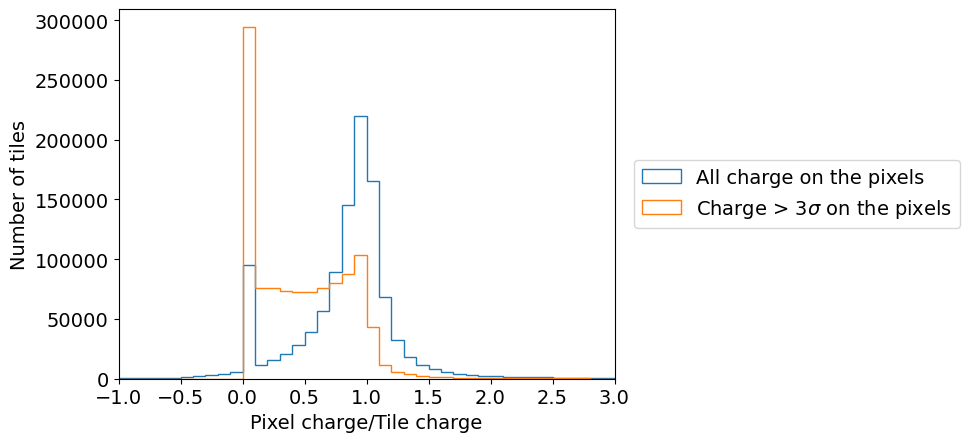

In [14]:
fig, ax = plt.subplots()

rBins = np.linspace(-1, 3, 41)
fonts = 14

ax.hist(dT2['ratio'], bins = rBins, histtype = 'step', label = 'All charge on the pixels')
ax.hist(dT2['ratio_3sd'], bins = rBins, histtype = 'step', label = r'Charge > 3$\sigma$ on the pixels')

ax.set_xlabel('Pixel charge/Tile charge', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([-1, 3])
ax.tick_params(axis = "both", labelsize = fonts)
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

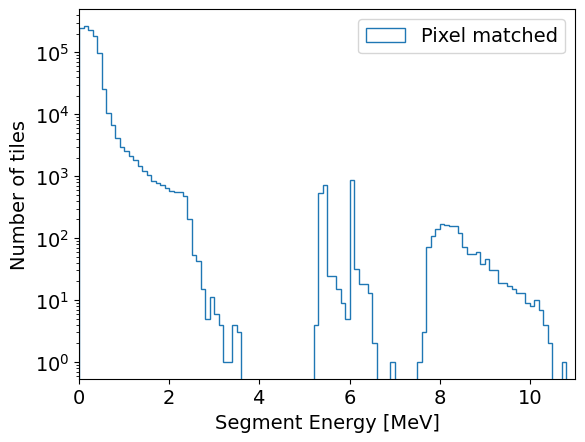

In [15]:
fig, ax = plt.subplots()

eBins = np.linspace(0, 11, 111)
fonts = 14

ax.hist(dT2['E'], bins = eBins, histtype = 'step', label = 'Pixel matched')

ax.set_xlabel('Segment Energy [MeV]', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([0, 11])
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_yscale('log')
ax.legend(fontsize = fonts)

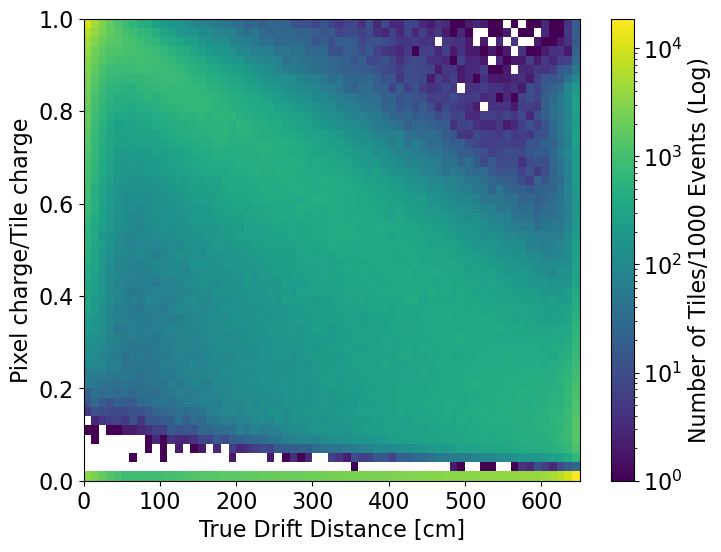

In [16]:
fig, ax = plt.subplots(figsize = (8, 6))

fonts = 16

h = ax.hist2d(325-dT2['z_avg'], dT2['ratio_3sd'], bins = (65, 50), range = [[0, 650], [0, 1]], cmap = 'viridis', norm = colors.LogNorm() )

ax.set_xlabel('True Drift Distance [cm]', fontsize = fonts)
ax.set_ylabel('Pixel charge/Tile charge', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_xlim([0, 650])
ax.set_ylim([0, 1])

cbar = fig.colorbar(h[3])
cbar.ax.tick_params( labelsize = fonts)     # ticks (numbers)
cbar.set_label("Number of Tiles/1000 Events (Log)", fontsize = fonts) 